In [ ]:
import numpy as np
from skimage.util import view_as_windows
import os
import shutil
import gc
from tensorflow.data import Dataset
from tensorflow import TensorSpec
import h5py
from sklearn.utils import shuffle
from tensorflow.keras import layers,models
from tensorflow.data import AUTOTUNE
from tensorflow import optimizers
from tensorflow import losses
from tensorflow.keras import callbacks
from tensorflow.keras import backend
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers

In [ ]:
def extract_patches(image, patch_size=(19, 19), stride=14): #было stride = 19
    h, w, u = image.shape
    m, n = patch_size
    if m > h or n > w:
        raise ValueError("Patch size is larger than image dimensions")
    pad_h = m // 2
    pad_w = n // 2
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='reflect')
    patches = view_as_windows(padded_image, (m, n, u), step=stride)
    patches = patches.reshape(-1, m, n, u)
    return patches


In [ ]:
imgs = [
    "/content/drive/MyDrive/hsi data/canola/canola_1.npy",
    "/content/drive/MyDrive/hsi data/canola/canola_2.npy",
    "/content/drive/MyDrive/hsi data/redroot/redroot_pigweed_1.npy",
    "/content/drive/MyDrive/hsi data/redroot/redroot_pigweed_2.npy",
    "/content/drive/MyDrive/hsi data/redroot/redroot_pigweed_3.npy",
    "/content/drive/MyDrive/hsi data/redroot/redroot_pigweed_4.npy",
    "/content/drive/MyDrive/hsi data/kochia/tmp/kochia_1.npy",
    "/content/drive/MyDrive/hsi data/kochia/tmp/kochia_2.npy",
    "/content/drive/MyDrive/hsi data/waterhemp/tmp/waterhemp_1.npy",
    "/content/drive/MyDrive/hsi data/waterhemp/tmp/waterhemp_2.npy",
    "/content/drive/MyDrive/hsi data/sugarbeet/sugarbeet_1.npy",
    "/content/drive/MyDrive/hsi data/sugarbeet/sugarbeet_2.npy",
    "/content/drive/MyDrive/hsi data/soybean/soybean_1.npy",
    "/content/drive/MyDrive/hsi data/soybean/soybean_2.npy",
    "/content/drive/MyDrive/hsi data/ragweed/ragweed_1.npy",
    "/content/drive/MyDrive/hsi data/ragweed/ragweed_2.npy",
]

class_mapping = {
    "canola": 0,
    "kochia": 1,
    "ragweed": 2,
    "redroot": 3,
    "soybean": 4,
    "sugarbeet": 5,
    "waterhemp": 6,
}
T=70
train_images = [0, 2, 4, 6, 8, 10, 12,14]
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pca = IncrementalPCA(T)

batch_size = 5000
B=224
counter = 0
for path in imgs:
    if counter in train_images:
      img = np.load(path).reshape(-1, B)
      for i in range(0, img.shape[0], batch_size):
          scaler.partial_fit(img[i:i+batch_size])
    counter+=1

counter = 0
for path in imgs:
  if counter in train_images:
    img = np.load(path).reshape(-1, B)
    img_scaled = scaler.transform(img)
    for i in range(0, img_scaled.shape[0], batch_size):
        pca.partial_fit(img_scaled[i:i+batch_size])
  counter+=1


hdf5_path = "/content/X_y_patches.h5"
n_samples = len(imgs)

with h5py.File(hdf5_path, "w") as f:
    for i, path in enumerate(imgs):
        img = np.load(path)


        R,C,B = img.shape
        img = img.reshape((R*C,B))

        img = scaler.transform(img)
        img = pca.transform(img)

        img = img.reshape((R,C,T))


        patches = extract_patches(img)
        num_patches = patches.shape[0]
        patch_shape = patches.shape[1:]

        class_label = os.path.splitext(os.path.basename(path))[0].split("_")[0]
        class_id = class_mapping[class_label]
        print(patches.shape)
        f.create_dataset(f"X_{i}", data=patches, dtype="float32")
        f.create_dataset(f"y_{i}", data=np.array(class_id, dtype="int32"))

(2412, 19, 19, 70)
(2079, 19, 19, 70)
(391, 19, 19, 70)
(567, 19, 19, 70)
(500, 19, 19, 70)
(420, 19, 19, 70)
(1275, 19, 19, 70)
(1404, 19, 19, 70)
(2628, 19, 19, 70)
(2555, 19, 19, 70)
(1830, 19, 19, 70)
(1768, 19, 19, 70)
(2139, 19, 19, 70)
(2232, 19, 19, 70)
(1612, 19, 19, 70)
(1674, 19, 19, 70)


In [ ]:
# Датасеты
train_images = [0, 2, 4, 6, 8, 10, 12,14]
val_images = [1, 3, 5, 7, 9, 11,13,15]

T=70
hdf5_path = "/content/X_y_patches.h5"
def make_generator(hdf5_path, image_indices):
    def generator():
        with h5py.File(hdf5_path, "r") as f:
            for idx in image_indices:
                X = f[f"X_{idx}"][:]
                y = f[f"y_{idx}"][()]
                tmp = np.zeros((7,))
                tmp[y] = 1
                labels = np.tile(tmp, (X.shape[0],1))
                #labels = np.full(X.shape[0], y, dtype=np.int32)
                yield X, labels
    return generator

dataset_train = Dataset.from_generator(
    make_generator(hdf5_path, train_images),
    output_signature=(
        TensorSpec(shape=(None, 19, 19, T), dtype=np.float32),
        TensorSpec(shape=(None,7), dtype=np.int32)
    )
).flat_map(lambda x, y: Dataset.from_tensor_slices((x, y))).shuffle(buffer_size=10000).batch(32).prefetch(AUTOTUNE)
dataset_val = Dataset.from_generator(
    make_generator(hdf5_path, val_images),
    output_signature=(
        TensorSpec(shape=(None, 19, 19, T), dtype=np.float32),
        TensorSpec(shape=(None,7), dtype=np.int32)
    )
).flat_map(lambda x, y: Dataset.from_tensor_slices((x, y))).batch(32).prefetch(AUTOTUNE)



In [ ]:
def build_model(input_shape = (19,19,T)):
    inp = layers.Input(input_shape)
    inp = layers.Reshape((19,19,T,1))(inp)
    x = layers.Conv3D(64, (3,3,9), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.Conv3D(128, (3,3,5), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(200, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(7, activation="softmax")(x)
    model = models.Model(inp, output)
    return model

In [ ]:
model = build_model()
print(model.summary())


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_41CLONE            │ (None, 19, 19, 70, 1)  │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 19, 19, 70, 64) │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 19, 19, 70, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 9, 9, 35, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 9, 9, 35, 128)  │       368,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 9, 9, 35, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        25,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,407 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,991 (1.53 MB)

 Trainable params: 401,607 (1.53 MB)

 Non-trainable params: 384 (1.50 KB)

None


In [ ]:
opt = optimizers.Adam(learning_rate = 1e-5)
model.compile(optimizer=opt,loss = losses.CategoricalCrossentropy(),metrics = ["accuracy"])  #Sparse

chechpoint = callbacks.ModelCheckpoint("/content/drive/MyDrive/hsi data/model_calib2.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only = False)
tb = callbacks.TensorBoard(
    log_dir="/content/logs",
    histogram_freq=1)

In [ ]:
history = model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=70,
    callbacks=[chechpoint, tb]
)

In [ ]:
model.load_weights("/content/drive/MyDrive/hsi data/2d-3d_ver_pca2.weights.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model("/content/drive/MyDrive/hsi data/model_calib2.keras")
preds = model.predict(dataset_val)
preds = np.argmax(preds,axis=1)

true_labels = []
for patches, labels in dataset_val:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

[0 0 0 ... 2 2 2]


<Axes: >

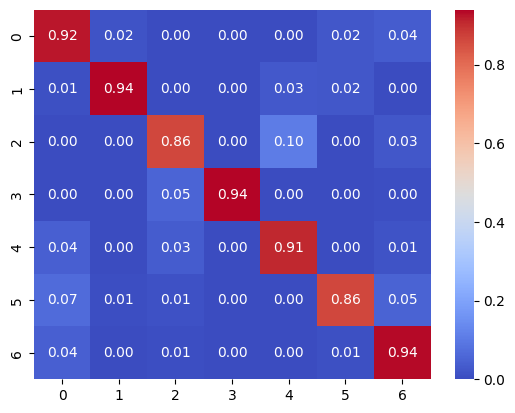

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
true_labels_single = np.argmax(true_labels, axis=1)
print(true_labels_single)
cm = confusion_matrix(true_labels_single, preds, normalize='true')
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(true_labels, preds))

              precision    recall  f1-score   support

           0       0.77      0.94      0.85      2079
           1       0.98      0.91      0.94      1404
           2       0.89      0.86      0.88      1674
           3       0.99      0.94      0.96       987
           4       0.87      0.93      0.90      2232
           5       0.91      0.87      0.89      1768
           6       0.95      0.82      0.88      2555

    accuracy                           0.89     12699
   macro avg       0.91      0.90      0.90     12699
weighted avg       0.90      0.89      0.89     12699



467 890 449 872


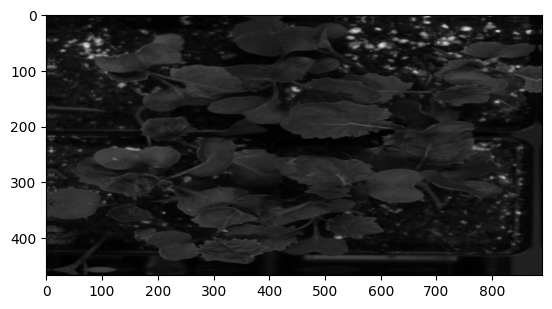

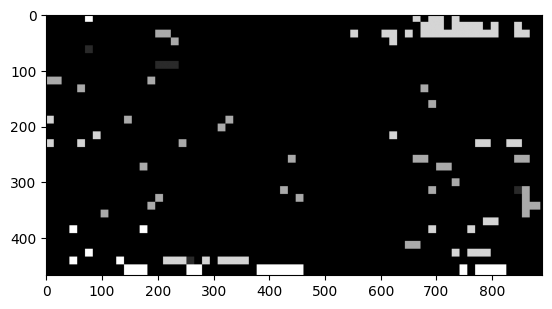

In [ ]:
import cv2
img = np.load('/content/drive/MyDrive/hsi data/canola/canola_2.npy')
band_to_display = hsi_image[:, :, hsi_image.shape[2] // 2]

r,c,b = img.shape
img = img.reshape((r*c,b))
img = scaler.transform(img)
img = pca.transform(img)
img = img.reshape((r,c,70))
patches = extract_patches(img)
vpreds = model.predict(patches)
vpreds = np.argmax(vpreds,axis=1)


gray = band_to_display
m, n = (19,19)
pad_h = m // 2
pad_w = n // 2
gray = np.pad(gray, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
H,W = gray.shape
print(H,W,r,c)
plt.imshow(gray,cmap='gray')
plt.show()
counter = 0
gray = gray.astype(np.int64)
counter = 0
for i in range(0, H - 19 + 1, 14):
    for j in range(0, W - 19 + 1, 14):
        if counter >= len(vpreds):
            break
        gray[i:i+19, j:j+19] = vpreds[counter] * 36
        counter += 1

gray = np.clip(gray,0,255)
gray = gray.astype(np.int64)
plt.imshow(gray,cmap="gray")
plt.show()

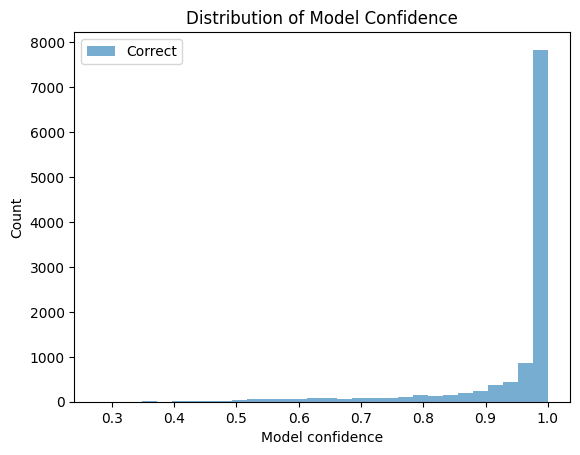

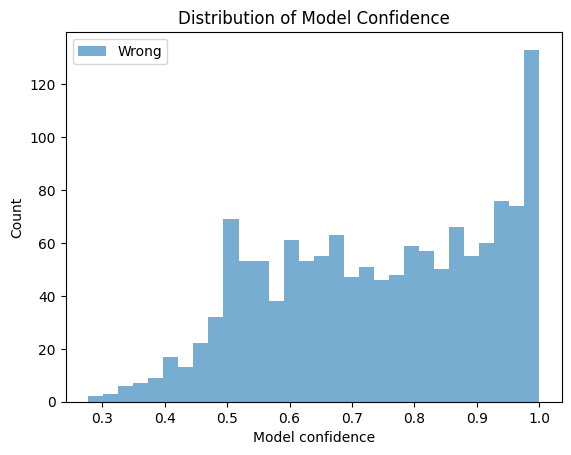

In [ ]:
probs = model.predict(dataset_val)
confidences = np.max(probs, axis=1)
preds = np.argmax(probs, axis=1)

correct_mask = preds == true_labels
wrong_mask = ~correct_mask

conf_correct = confidences[correct_mask]
conf_wrong = confidences[wrong_mask]

plt.hist(conf_correct, bins=30, alpha=0.6, label='Correct')
plt.xlabel('Model confidence')
plt.ylabel('Count')
plt.legend()
plt.title('Distribution of Model Confidence')
plt.show()
plt.hist(conf_wrong, bins=30, alpha=0.6, label='Wrong')
plt.xlabel('Model confidence')
plt.ylabel('Count')
plt.legend()
plt.title('Distribution of Model Confidence')
plt.show()


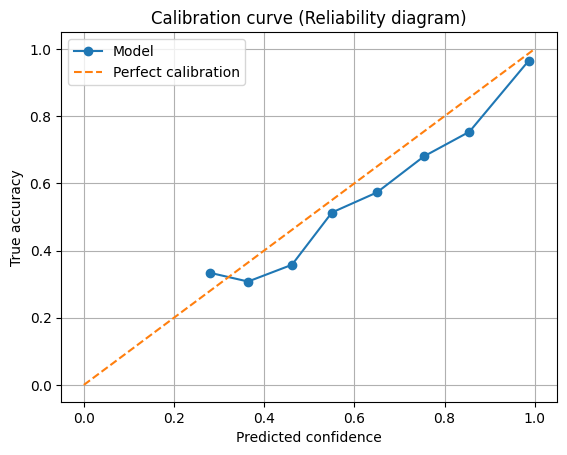

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

confidences = np.max(probs, axis=1)
predicted_class = np.argmax(probs, axis=1)
correct = (predicted_class == true_labels).astype(int)

prob_true, prob_pred = calibration_curve(correct, confidences, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted confidence')
plt.ylabel('True accuracy')
plt.title('Calibration curve (Reliability diagram)')
plt.legend()
plt.grid()
plt.show()


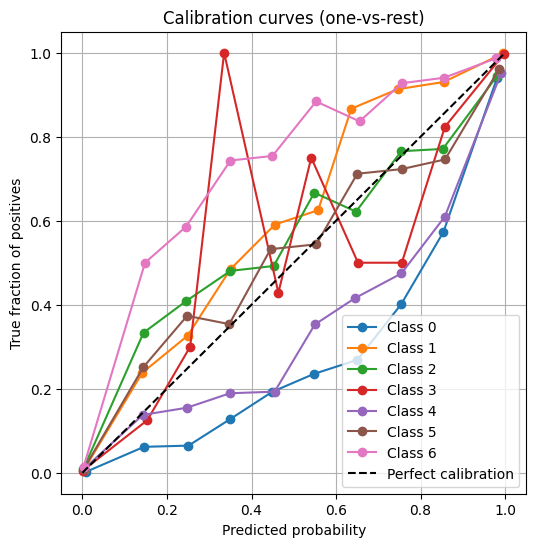

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

n_classes = probs.shape[1]
plt.figure(figsize=(6, 6))

for c in range(n_classes):
    y_true_class = (true_labels == c).astype(int)
    prob_true, prob_pred = calibration_curve(y_true_class, probs[:, c], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Class {c}')

plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('True fraction of positives')
plt.title('Calibration curves (one-vs-rest)')
plt.legend()
plt.grid(True)
plt.show()
